In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("store_sales.csv")

df.head()

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases
0,1,58,Female,Accessories,Handbag,115.50,Autumn,Card,3.5,18,4
1,2,40,Male,Mens Clothing,Shirt,103.43,Spring,Card,4.1,13,4
2,3,66,Female,Sports,Football,35.45,Spring,Card,3.3,11,3
3,4,39,Female,Accessories,Handbag,153.31,Spring,Card,4.4,13,4
4,5,23,Female,Home,Curtains,151.43,Winter,Card,4.1,20,10


#INITIAL INSPECTION

In [7]:
print("Number of rows and columns:", df.shape)
print("Column names:")
print(df.columns.tolist())
print(df.dtypes)
print(df.isnull().sum())

Number of rows and columns: (5000, 11)
Column names:
['CustomerID', 'Age', 'Gender', 'Category', 'ItemPurchased', 'Amount', 'Season', 'PaymentMethod', 'ItemRating', 'DiscountApplied(%)', 'PreviousPurchases']
CustomerID              int64
Age                     int64
Gender                 object
Category               object
ItemPurchased          object
Amount                float64
Season                 object
PaymentMethod          object
ItemRating            float64
DiscountApplied(%)      int64
PreviousPurchases       int64
dtype: object
CustomerID            0
Age                   0
Gender                0
Category              0
ItemPurchased         0
Amount                0
Season                0
PaymentMethod         0
ItemRating            0
DiscountApplied(%)    0
PreviousPurchases     0
dtype: int64


##OBSERVATION

The dataset contains 5,000 customer purchase records and 11 variables. The dataset includes customer demographics, product information, purchase amount, season, payment method, item ratings, discounts, and previous purchase history. All columns contain zero missing values, indicating that the dataset is complete and does not require missing-value treatment at this stage. The dataset contains both numerical and categorical variables, which makes it suitable for exploratory data analysis.

##DESCRIPTIVE ANALYSIS


In [8]:
numeric_columns = df.select_dtypes(include='number').columns

print("Numerical columns:")
print(numeric_columns.tolist())

Numerical columns:
['CustomerID', 'Age', 'Amount', 'ItemRating', 'DiscountApplied(%)', 'PreviousPurchases']


In [9]:
df[numeric_columns].describe()

,CustomerID,Age,Amount,ItemRating,DiscountApplied(%),PreviousPurchases
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,45.224800,285.090522,3.784160,14.983600,5.008800
std,1443.520003,14.564995,551.454382,0.681796,5.988063,2.194285
min,1.000000,20.000000,5.080000,1.100000,0.000000,0.000000
25%,1250.750000,33.000000,70.547500,3.300000,11.000000,3.000000
50%,2500.500000,45.000000,122.485000,3.800000,15.000000,5.000000
75%,3750.250000,58.000000,184.535000,4.300000,19.000000,6.000000
max,5000.000000,70.000000,2997.940000,5.000000,36.000000,13.000000


##MEAN

In [10]:
print("Mean:")
print(df[numeric_columns].mean())

Mean:
CustomerID            2500.500000
Age                     45.224800
Amount                 285.090522
ItemRating               3.784160
DiscountApplied(%)      14.983600
PreviousPurchases        5.008800
dtype: float64


##MEDIAN

In [11]:
print("\nMedian:")
print(df[numeric_columns].median())


Median:
CustomerID            2500.500
Age                     45.000
Amount                 122.485
ItemRating               3.800
DiscountApplied(%)      15.000
PreviousPurchases        5.000
dtype: float64


##MODE

In [12]:
print("\nMode:")
print(df[numeric_columns].mode().iloc[0])


Mode:
CustomerID              1.0
Age                    42.0
Amount                108.5
ItemRating              3.8
DiscountApplied(%)     16.0
PreviousPurchases       5.0
Name: 0, dtype: float64


##STANDARD DEVIATION

In [13]:
print("\nStandard Deviation:")
print(df[numeric_columns].std())


Standard Deviation:
CustomerID            1443.520003
Age                     14.564995
Amount                 551.454382
ItemRating               0.681796
DiscountApplied(%)       5.988063
PreviousPurchases        2.194285
dtype: float64


##OBSERVATIONS
The descriptive analysis shows that the average customer age is approximately 45 years, with a median of 45 years. The average purchase amount is 285.09, while the median is considerably lower at 122.49, indicating that some higher-value purchases may be increasing the overall average. Item ratings are concentrated around 3.8, suggesting relatively consistent customer ratings. The average discount applied is approximately 15%, and customers have an average of about 5 previous purchases. Overall, purchase amount shows considerably greater variation than the other customer and purchase-related variables.

##CUSTOMER DEMOGRAPHIC ANALYSIS

In [14]:
age_bins = [0, 25, 35, 45, 55, 100]

age_labels = [
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '56+'
]

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=age_bins,
    labels=age_labels
)

df['AgeGroup'].value_counts().sort_index()

,count
AgeGroup,
18-25,576
26-35,928
36-45,1007
46-55,1007
56+,1482


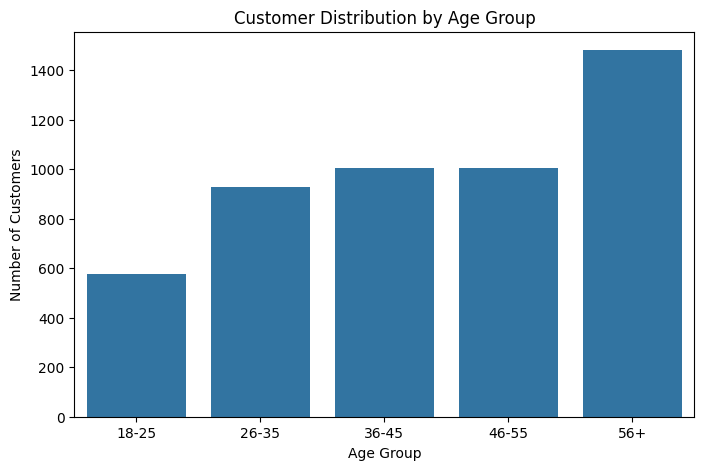

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='AgeGroup'
)

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')

plt.show()

##OBSERVATION

 The 56+ age group represents the largest proportion of customers, with approximately 1,480 customers. The 36–45 and 46–55 age groups also have substantial representation, while the 18–25 age group has the fewest customers. This indicates that the customer base is more concentrated among middle-aged and older customers than younger customers.

##GENDER BREAKDOWN

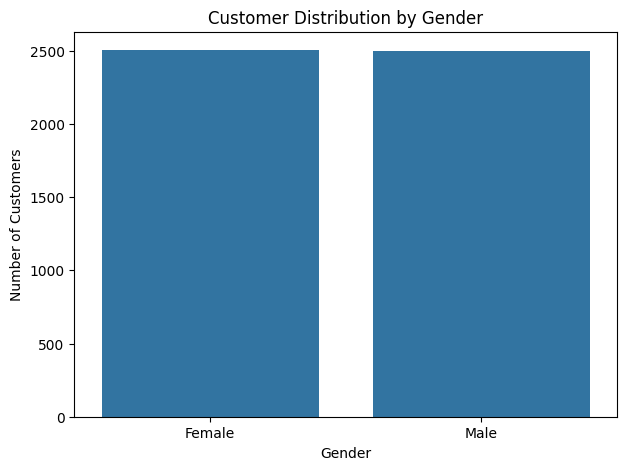

In [16]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Gender'
)

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

##OBSERVATION

The gender distribution is almost evenly split between female and male customers, with each group representing approximately half of the customer base. This indicates that the dataset does not have a significant gender imbalance, suggesting that marketing strategies should consider both groups rather than focusing heavily on one gender.

##PRODUCT ANALYSIS

In [17]:
top_products = (
    df.groupby('ItemPurchased')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

ItemPurchased
Laptop          265862.26
Mobile Phone    233026.68
Headphones      204660.34
Smart Watch     191853.07
Sneakers         47798.27
Formal Shoes     47301.48
Sandals          46042.49
Dumbbells        39047.34
Yoga Mat         38717.61
Football         37833.16
Name: Amount, dtype: float64


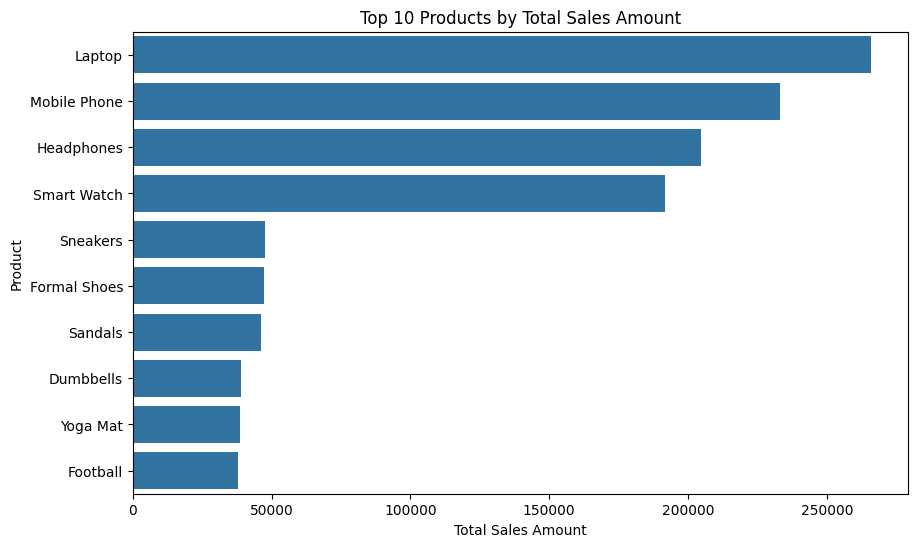

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title('Top 10 Products by Total Sales Amount')
plt.xlabel('Total Sales Amount')
plt.ylabel('Product')

plt.show()

##OBSERVATION

Laptops generated the highest total sales amount at approximately 265,862, followed by Mobile Phones at 233,027, Headphones at 204,660, and Smart Watches at 191,853. These four products generated substantially higher sales than the remaining products in the top 10. This indicates that electronic products are major contributors to the company's sales revenue. The business could prioritize inventory availability and promotional campaigns for these high-performing products while exploring opportunities to increase sales of lower-performing product categories.

##REVENUE BY PRODUCT CATEGORY

In [19]:
category_sales = (
    df.groupby('Category')['Amount']
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Electronics        895402.35
Footwear           141142.24
Sports             115598.11
Womens Clothing     61718.41
Mens Clothing       59680.43
Accessories         47633.83
Home                46374.22
Beauty              43887.06
Groceries           14015.96
Name: Amount, dtype: float64


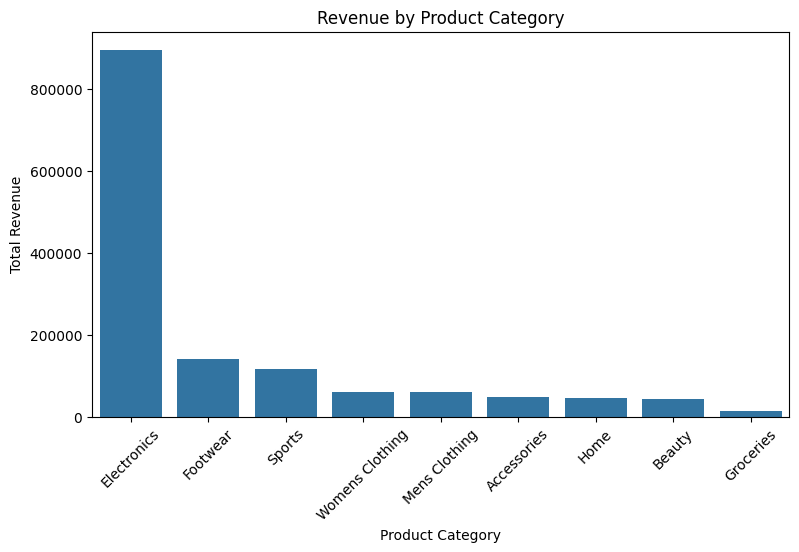

In [20]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)

plt.show()

##OBSERVATION

Electronics generated the highest revenue at approximately 895,402, significantly exceeding all other product categories. Footwear was the second-highest category with approximately 141,142 in revenue, followed by Sports at approximately 115,598. Clothing, Accessories, Home, Beauty, and Groceries contributed comparatively lower revenue. This indicates that Electronics is the primary revenue-generating category and should receive strong inventory and marketing support, while lower-performing categories may require targeted promotions or product-level analysis to improve sales.

##CORRELATION HEATMAP

In [21]:
analysis_columns = [
    'Age',
    'Amount',
    'ItemRating',
    'DiscountApplied(%)',
    'PreviousPurchases'
]

correlation_matrix = df[analysis_columns].corr()

print(correlation_matrix)

                         Age    Amount  ItemRating  DiscountApplied(%)  \
Age                 1.000000  0.003056    0.003723            0.032820   
Amount              0.003056  1.000000    0.000752            0.004291   
ItemRating          0.003723  0.000752    1.000000            0.158709   
DiscountApplied(%)  0.032820  0.004291    0.158709            1.000000   
PreviousPurchases   0.029124 -0.006010    0.115781            0.729560   

                    PreviousPurchases  
Age                          0.029124  
Amount                      -0.006010  
ItemRating                   0.115781  
DiscountApplied(%)           0.729560  
PreviousPurchases            1.000000  


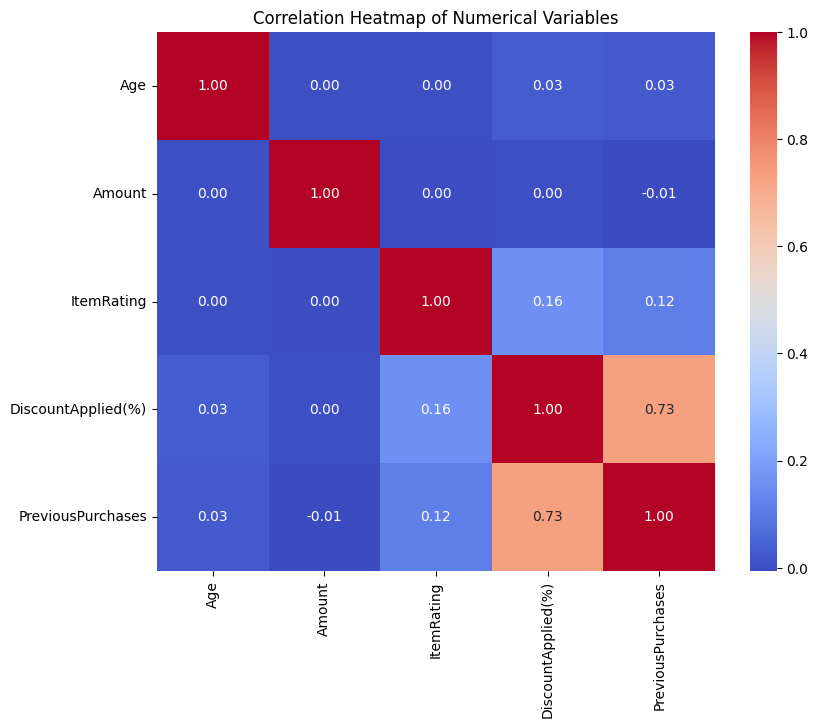

In [22]:
plt.figure(figsize=(9,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables')

plt.show()

##OBSERVATION

The correlation analysis shows a strong positive relationship of approximately 0.73 between discount applied and previous purchases, indicating that customers with more previous purchases tend to receive higher discounts in this dataset. Most of the other numerical variables show weak or negligible correlations. In particular, purchase amount has almost no linear relationship with age or previous purchases. The strong relationship between discounts and previous purchases may indicate that repeat customers are more likely to receive higher discounts or promotional benefits; however, correlation alone does not establish a causal relationship.

##SEASONAL SALES ANALYSIS

In [24]:
season_sales = (
    df.groupby('Season')['Amount']
    .sum()
    .sort_values(ascending=False)
)

print(season_sales)

Season
Spring    376029.40
Winter    354884.96
Summer    350860.36
Autumn    343677.89
Name: Amount, dtype: float64


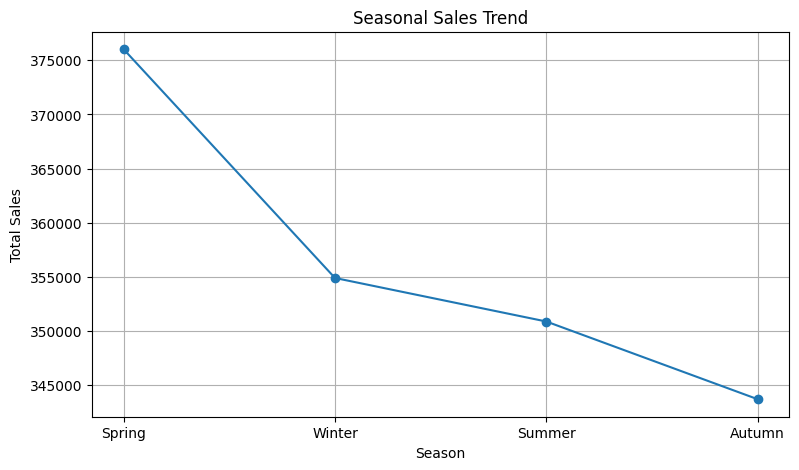

In [25]:
plt.figure(figsize=(9,5))

plt.plot(
    season_sales.index,
    season_sales.values,
    marker='o'
)

plt.title('Seasonal Sales Trend')
plt.xlabel('Season')
plt.ylabel('Total Sales')
plt.grid(True)

plt.show()

##OBSERVATION

Spring recorded the highest total sales at approximately 376,029, followed by Winter at 354,885 and Summer at 350,860. Autumn recorded the lowest sales at approximately 343,678. Although Spring performed slightly better, the relatively small difference between the seasons indicates that sales are distributed fairly consistently throughout the year.

##a scatter plot of Previous Purchases vs Discount Applied.

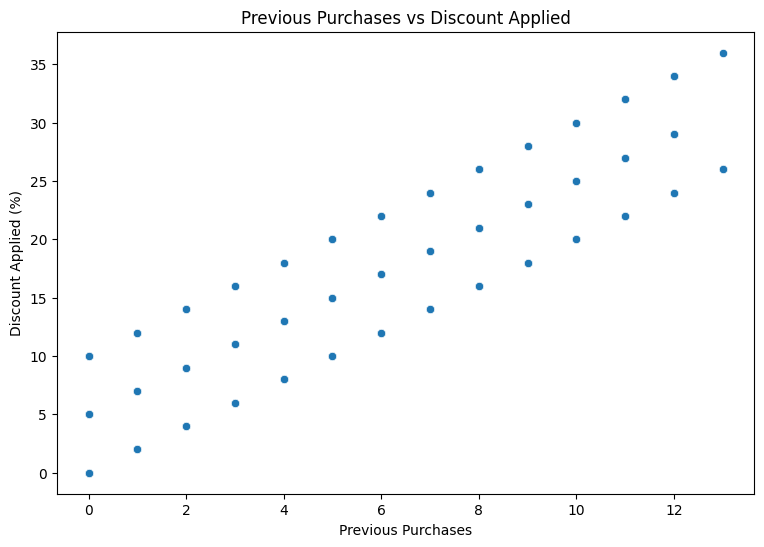

In [23]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='PreviousPurchases',
    y='DiscountApplied(%)'
)

plt.title('Previous Purchases vs Discount Applied')
plt.xlabel('Previous Purchases')
plt.ylabel('Discount Applied (%)')

plt.show()

##OBSERVATION
The scatter plot shows a clear positive relationship between previous purchases and the discount applied. Customers with a higher number of previous purchases generally receive higher discounts. This pattern is consistent with the strong positive correlation of 0.73 observed in the correlation analysis. The result suggests that repeat customers may be receiving greater promotional benefits, which could support customer retention. However, the relationship should not be interpreted as proof that higher discounts cause customers to make more purchases.


##KEY INSIGHT

Customer demographics: Customers aged 56+ represent the largest age group, while customers aged 18–25 represent the smallest group. The gender distribution is almost evenly split between male and female customers.

Product performance: Electronics products dominate sales, with Laptops, Mobile Phones, Headphones, and Smart Watches being the strongest individual products.

Category performance: Electronics generated approximately 895,402 in total sales, significantly higher than all other categories.

Customer purchasing behaviour: The average customer has approximately 5 previous purchases. The strong positive correlation between previous purchases and discounts suggests that repeat customers tend to receive higher discounts.

Seasonal performance: Spring recorded the highest sales, while Autumn recorded the lowest. However, the differences between seasons are relatively small, indicating fairly consistent sales throughout the seasons.

Purchase amount variation: The mean purchase amount is substantially higher than the median, suggesting that some high-value purchases have a significant influence on overall sales.

##BUSINESS RECOMENDATION

 Prioritize Electronics inventory and marketing

 Develop targeted strategies for older customers

 Strengthen customer loyalty programs

 Investigate lower-performing categories

 Plan seasonal promotions strategically



##FINAL COMCLUSION

This exploratory data analysis provided insights into customer demographics, product performance, purchasing behaviour, and seasonal sales patterns. The analysis showed that Electronics is the strongest revenue-generating category, with Laptops, Mobile Phones, Headphones, and Smart Watches being the leading products. The customer base is concentrated among middle-aged and older customers, with the 56+ segment representing the largest group. The analysis also identified a strong positive relationship between previous purchases and discounts. Based on these findings, the business can improve performance by prioritizing high-performing products, developing targeted customer strategies, strengthening loyalty programs, and improving the performance of lower-revenue categories.

Data limitation: Monthly and quarterly sales trends could not be calculated because the dataset does not contain transaction-level date information. Seasonal analysis was used instead based on the available Season variable.